In [ ]:
import pandas as pd

df = pd.read_csv("Student_Performance.csv")
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [ ]:
df.isnull().sum()

df = df.drop_duplicates()
df = df.fillna(df.mean(numeric_only=True))

In [ ]:
df["internet_access"] = df["internet_access"].map({"yes":1,"no":0})
df["extra_activities"] = df["extra_activities"].map({"yes":1,"no":0})

df["parent_education"] = pd.to_numeric(df["parent_education"], errors="coerce")
df["parent_education"] = df["parent_education"].fillna(df["parent_education"].median())

print(df.head())
print(df.columns)

   student_id  age  gender school_type  parent_education  study_hours  \
0           1   14    male      public               NaN          3.1   
1           2   18  female      public               NaN          3.7   
2           3   17  female     private               NaN          7.9   
3           4   16   other      public               NaN          1.1   
4           5   16  female      public               NaN          1.3   

   attendance_percentage  internet_access travel_time  extra_activities  \
0                   84.3              NaN     <15 min               NaN   
1                   87.8              NaN     >60 min               NaN   
2                   65.5              NaN     <15 min               NaN   
3                   58.1              NaN   15-30 min               NaN   
4                   61.0              NaN   30-60 min               NaN   

  study_method  math_score  science_score  english_score  overall_score  \
0        notes        42.7         

In [ ]:
from sklearn.model_selection import train_test_split

X = df[["study_hours","attendance_percentage","math_score","science_score","english_score","age"]]
y = df["overall_score"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape, X_test.shape)

(12000, 6) (3000, 6)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np

feature_cols = ["study_hours","attendance_percentage","math_score","science_score","english_score","age"]

X = df[feature_cols]
y = df["overall_score"]

In [ ]:
import numpy as np

feature_cols = ["study_hours","attendance_percentage","math_score","science_score","english_score","age"]

X = df[feature_cols]
y = df["overall_score"]

In [ ]:
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

X = df_clean[feature_cols]
y = df_clean["overall_score"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

results=[]

lr=LinearRegression()
lr.fit(X_train,y_train)
pred_lr=lr.predict(X_test)
results.append(["Linear",mean_squared_error(y_test,pred_lr),r2_score(y_test,pred_lr)])

poly=PolynomialFeatures(2)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

model=LinearRegression()
model.fit(X_train_poly,y_train)
pred_poly=model.predict(X_test_poly)
results.append(["Polynomial",mean_squared_error(y_test,pred_poly),r2_score(y_test,pred_poly)])

ridge=Ridge()
ridge.fit(X_train,y_train)
pred_ridge=ridge.predict(X_test)
results.append(["Ridge",mean_squared_error(y_test,pred_ridge),r2_score(y_test,pred_ridge)])

lasso=Lasso()
lasso.fit(X_train,y_train)
pred_lasso=lasso.predict(X_test)
results.append(["Lasso",mean_squared_error(y_test,pred_lasso),r2_score(y_test,pred_lasso)])

elastic=ElasticNet()
elastic.fit(X_train,y_train)
pred_elastic=elastic.predict(X_test)
results.append(["ElasticNet",mean_squared_error(y_test,pred_elastic),r2_score(y_test,pred_elastic)])

import pandas as pd
results_df=pd.DataFrame(results,columns=["Model","MSE","R2"])
print(results_df)

        Model        MSE        R2
0      Linear  16.929042  0.952754
1  Polynomial  16.935489  0.952736
2       Ridge  16.929037  0.952754
3       Lasso  17.896844  0.950053
4  ElasticNet  19.687110  0.945057


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

results = []

# Multiple Linear Regression
pred_lr = lr.predict(X_test)
results.append([
    "Linear",
    mean_squared_error(y_test, pred_lr),
    r2_score(y_test, pred_lr)
])

# Polynomial Regression
pred_poly = model.predict(X_test_poly)
results.append([
    "Polynomial",
    mean_squared_error(y_test, pred_poly),
    r2_score(y_test, pred_poly)
])

# Ridge Regression
pred_ridge = ridge.predict(X_test)
results.append([
    "Ridge",
    mean_squared_error(y_test, pred_ridge),
    r2_score(y_test, pred_ridge)
])

# Lasso Regression
pred_lasso = lasso.predict(X_test)
results.append([
    "Lasso",
    mean_squared_error(y_test, pred_lasso),
    r2_score(y_test, pred_lasso)
])

# Elastic Net Regression
pred_elastic = elastic.predict(X_test)
results.append([
    "ElasticNet",
    mean_squared_error(y_test, pred_elastic),
    r2_score(y_test, pred_elastic)
])

# Comparison table
results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2"])
print(results_df)

        Model        MSE        R2
0      Linear  16.929042  0.952754
1  Polynomial  16.935489  0.952736
2       Ridge  16.929037  0.952754
3       Lasso  17.896844  0.950053
4  ElasticNet  19.687110  0.945057


In [ ]:
print(results_df)

        Model        MSE        R2
0      Linear  16.929042  0.952754
1  Polynomial  16.935489  0.952736
2       Ridge  16.929037  0.952754
3       Lasso  17.896844  0.950053
4  ElasticNet  19.687110  0.945057


In [ ]:
print(model.intercept_)
print(model.coef_)

-3.6892244458717443
[ 4.10000109e-14  4.38863280e+00  2.53915374e-01  1.21288218e-01
  1.19743212e-01  1.84335346e-01  3.47532720e-01  5.43957407e-02
  8.61228615e-03 -2.60538035e-03 -7.82410520e-03 -4.29212288e-03
 -3.32126209e-02 -2.51752083e-04  5.76289022e-05 -5.57362362e-04
 -4.65317423e-04  6.79329929e-04  2.16857436e-05  2.35635516e-04
  3.83359694e-04  7.41092382e-04  1.19359076e-04  6.78280905e-04
  3.31647552e-03 -1.95299251e-04 -5.48767886e-04 -1.39294403e-02]


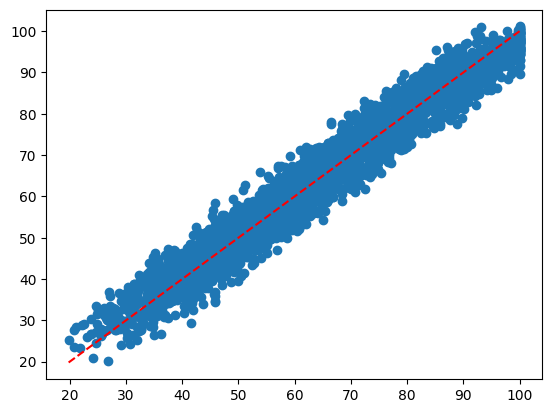

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test,pred_poly)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.show()

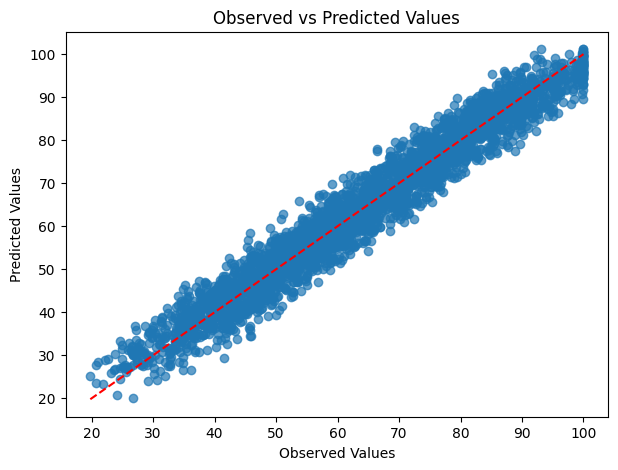

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, pred_poly, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Observed vs Predicted Values")
plt.show()

In [ ]:
def cat(x):
    if x<50: return "Low"
    elif x<75: return "Medium"
    else: return "High"

df["category"]=df["overall_score"].apply(cat)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

X=df[feature_cols]
y=df["category"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

models={
"Logistic":LogisticRegression(max_iter=1000),
"KNN":KNeighborsClassifier(),
"SVM":SVC(),
"Tree":DecisionTreeClassifier(),
"Forest":RandomForestClassifier()
}

for name,m in models.items():
    m.fit(X_train,y_train)
    pred=m.predict(X_test)
    print(name,
          accuracy_score(y_test,pred),
          precision_score(y_test,pred,average="weighted"),
          recall_score(y_test,pred,average="weighted"),
          f1_score(y_test,pred,average="weighted"))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic 0.8896666666666667 0.8900931020436224 0.8896666666666667 0.8898021477224517
KNN 0.8466666666666667 0.8465070463304598 0.8466666666666667 0.8465718759325576
SVM 0.8706666666666667 0.8705651578976512 0.8706666666666667 0.870598037399525
Tree 0.8406666666666667 0.8405194801097882 0.8406666666666667 0.8405835332920603
Forest 0.892 0.8921827302631579 0.892 0.8920735210226847


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Step 1: Create categorical target
def category(x):
    if x < 50:
        return "Low"
    elif x < 75:
        return "Medium"
    else:
        return "High"

df["category"] = df["overall_score"].apply(category)

# Step 2: Define features and target
X = df[["study_hours","attendance_percentage","math_score","science_score","english_score","age"]]
y = df["category"]

# Step 3: Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# Step 5: Results storage
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average="weighted")
    rec = recall_score(y_test, pred, average="weighted")
    f1 = f1_score(y_test, pred, average="weighted")

    errors = (pred != y_test).sum()

    results.append([name, cm, errors, acc, prec, rec, f1])

# Step 6: Create table
results_df = pd.DataFrame(results, columns=[
    "Model", "Confusion Matrix", "Errors (FP+FN)", "Accuracy",
    "Precision", "Recall", "F1-score"
])

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model                                Confusion Matrix  \
0  Logistic Regression    [[873, 0, 87], [0, 751, 85], [75, 66, 1063]]   
1                  KNN  [[809, 0, 151], [0, 720, 116], [119, 94, 991]]   
2                  SVM   [[836, 0, 124], [0, 737, 99], [83, 74, 1047]]   
3        Decision Tree  [[831, 0, 129], [0, 709, 127], [99, 99, 1006]]   
4        Random Forest    [[867, 0, 93], [0, 754, 82], [77, 66, 1061]]   

   Errors (FP+FN)  Accuracy  Precision    Recall  F1-score  
0             313  0.895667   0.896278  0.895667  0.895871  
1             480  0.840000   0.841606  0.840000  0.840525  
2             380  0.873333   0.875202  0.873333  0.873832  
3             454  0.848667   0.850380  0.848667  0.849202  
4             318  0.894000   0.894646  0.894000  0.894219  


In [ ]:
df["category"].value_counts()

,count
category,
Medium,6259
High,4771
Low,3970


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features=df[["study_hours","attendance_percentage","math_score","science_score","english_score"]]

scores=[]
for k in range(2,6):
    kmeans=KMeans(n_clusters=k)
    labels=kmeans.fit_predict(features)
    scores.append(silhouette_score(features,labels))

best_k=range(2,6)[scores.index(max(scores))]
print(best_k)

kmeans=KMeans(n_clusters=best_k)
df["cluster"]=kmeans.fit_predict(features)

2


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = df[["study_hours","attendance_percentage","math_score","science_score","english_score"]]

scores = []
for k in range(2,6):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(features)
    scores.append(silhouette_score(features, labels))

best_k = range(2,6)[scores.index(max(scores))]
print("Best k:", best_k)

Best k: 2


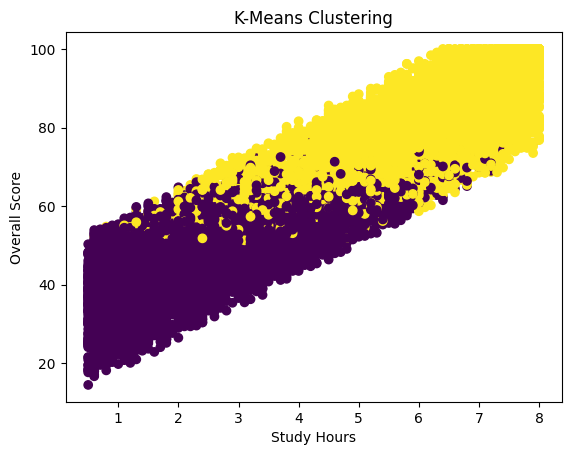

In [ ]:
kmeans = KMeans(n_clusters=best_k)
df["cluster"] = kmeans.fit_predict(features)

import matplotlib.pyplot as plt

plt.scatter(df["study_hours"], df["overall_score"], c=df["cluster"])
plt.xlabel("Study Hours")
plt.ylabel("Overall Score")
plt.title("K-Means Clustering")
plt.show()


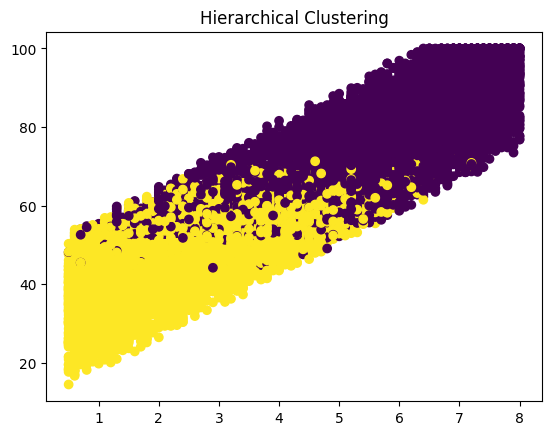

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=best_k)
df["hc_cluster"] = hc.fit_predict(features)

plt.scatter(df["study_hours"], df["overall_score"], c=df["hc_cluster"])
plt.title("Hierarchical Clustering")
plt.show()